In [1]:
import pandas as pd



print(" Loading finalized 30-feature datasets into memory...")
X_train_final = pd.read_parquet(f"X_train_final.parquet")
X_val_final   = pd.read_parquet(f"X_val_final.parquet")
X_test_final  = pd.read_parquet(f"X_test_final.parquet")

print(f" Data loaded successfully! Shapes match final footprint:")
print(f" -> X_train_final: {X_train_final.shape}")
print(f" -> X_val_final:   {X_val_final.shape}")
print(f" -> X_test_final:  {X_test_final.shape}")

 Loading finalized 30-feature datasets into memory...
 Data loaded successfully! Shapes match final footprint:
 -> X_train_final: (113099, 30)
 -> X_val_final:   (28275, 30)
 -> X_test_final:  (8555, 30)


In [4]:
import pandas as pd

# Load y vectors (targets) directly
# Assuming these were saved alongside your X_final dataframes
y_train = pd.read_parquet("y_train.parquet")
y_val   = pd.read_parquet("y_val.parquet")
y_test  = pd.read_parquet("y_test.parquet")

print(f" Targets loaded successfully:")
print(f" -> y_train: {y_train.shape}")
print(f" -> y_val:   {y_val.shape}")
print(f" -> y_test:  {y_test.shape}")

 Targets loaded successfully:
 -> y_train: (113099, 1)
 -> y_val:   (28275, 1)
 -> y_test:  (8555, 1)


In [6]:
X_train_final.columns

Index(['low_card__PPM_Y', 'low_card__OCCUPANCY_STATUS_P',
       'low_card__OCCUPANCY_STATUS_S', 'low_card__LOAN_PURPOSE_N',
       'low_card__LOAN_PURPOSE_P', 'low_card__CHANNEL_T',
       'low_card__PROPERTY_TYPE_MH', 'low_card__PROPERTY_TYPE_PU',
       'low_card__PROPERTY_TYPE_SF', 'high_card__SELLER_NAME',
       'high_card__SERVICER_NAME', 'high_card__PROPERTY_STATE',
       'high_card__POSTAL_CODE', 'high_card__MSA', 'remainder__CREDIT_SCORE',
       'remainder__MI_PERCENT', 'remainder__NUMBER_UNITS', 'remainder__CLTV',
       'remainder__DTI', 'remainder__ORIGINAL_UPB',
       'remainder__ORIGINAL_INTEREST_RATE', 'remainder__ORIGINAL_LOAN_TERM',
       'remainder__NUMBER_BORROWERS', 'remainder__RATE_INCREASE_MAGNITUDE',
       'remainder__CSUSHPISA', 'remainder__BRMHELOC01',
       'remainder__MORTGAGE30US', 'remainder__DRSFRMACBS',
       'remainder__CREDIT_SCORE_IS_MISSING', 'remainder__DTI_IS_MISSING'],
      dtype='str')

In [ ]:
X_train_final

,low_card__PPM_Y,low_card__OCCUPANCY_STATUS_P,low_card__OCCUPANCY_STATUS_S,low_card__LOAN_PURPOSE_N,low_card__LOAN_PURPOSE_P,low_card__CHANNEL_T,low_card__PROPERTY_TYPE_MH,low_card__PROPERTY_TYPE_PU,low_card__PROPERTY_TYPE_SF,high_card__SELLER_NAME,...,remainder__ORIGINAL_INTEREST_RATE,remainder__ORIGINAL_LOAN_TERM,remainder__NUMBER_BORROWERS,remainder__RATE_INCREASE_MAGNITUDE,remainder__CSUSHPISA,remainder__BRMHELOC01,remainder__MORTGAGE30US,remainder__DRSFRMACBS,remainder__CREDIT_SCORE_IS_MISSING,remainder__DTI_IS_MISSING
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,-0.412994,...,0.2,0.0,0.0,0.000000,0.457838,0.140252,-0.344715,0.500000,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,1.547690,...,-0.4,0.0,-1.0,0.693147,0.521222,0.133739,0.074797,0.500000,0.0,0.0
2,0.0,-1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,-0.453112,...,1.6,0.0,-1.0,0.000000,-0.474816,0.153278,0.391870,1.426471,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,-0.130461,...,-0.2,0.0,-1.0,1.609438,0.459111,0.000000,1.091057,-0.176471,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,1.0,-1.0,-0.111726,...,-0.6,0.0,0.0,0.000000,-1.139078,-1.299175,-1.843902,-0.220588,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113094,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,-0.453112,...,-0.4,0.0,0.0,0.000000,0.521222,0.133739,0.074797,0.500000,0.0,0.0
113095,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.578382,...,0.6,0.0,-1.0,0.000000,0.367289,0.077290,1.365854,-0.176471,0.0,0.0
113096,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-1.0,1.133993,...,-0.4,0.0,0.0,0.000000,-0.395727,0.227529,1.008130,1.426471,0.0,0.0
113097,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,0.0,-1.0,-0.453112,...,-0.4,0.0,-1.0,0.000000,0.199491,-0.487191,-0.380488,-0.191176,0.0,0.0


In [ ]:
print(" Splitting pipelines: Isolating Naive (Micro) vs. Stress-Tested (Macro) environments...")

# 1. Define the specific macroeconomic stress indicators
macro_columns = [
    'remainder__CSUSHPISA',     # Housing Price Index
    'remainder__BRMHELOC01',    # HELOC default rates / macro credit stress
    'remainder__MORTGAGE30US',  # 30-Year Fixed Mortgage Rate
    'remainder__DRSFRMACBS'     # Delinquency Rate on Single-Family Residential Mortgages
]

# 2. Create the Naive (Micro) Baseline Matrices (26 features)
X_train_micro = X_train_final.drop(columns=macro_columns)
X_val_micro   = X_val_final.drop(columns=macro_columns)
X_test_micro  = X_test_final.drop(columns=macro_columns)

# 3. Create the Stress-Tested (Macro) Matrices (all 30 features)
X_train_macro = X_train_final.copy()
X_val_macro   = X_val_final.copy()
X_test_macro  = X_test_final.copy()

print("\n Environments successfully split!")
print(f" -> MICRO (Standard Underwriting) Train Shape: {X_train_micro.shape}")
print(f" -> MACRO (Stress-Tested) Train Shape:         {X_train_macro.shape}")

 Splitting pipelines: Isolating Naive (Micro) vs. Stress-Tested (Macro) environments...

 Environments successfully split!
 -> MICRO (Standard Underwriting) Train Shape: (113099, 26)
 -> MACRO (Stress-Tested) Train Shape:         (113099, 30)


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

print(" Initializing True Naive Baseline (Logit on Micro Data)...")

# Initialize the Logit model (SAGA + ElasticNet)
logit_micro = LogisticRegression(
    penalty='elasticnet',    
    l1_ratio=0.5,            
    C=1.0, 
    class_weight='balanced', 
    solver='saga',           
    max_iter=2000,           
    random_state=42,
    n_jobs=-1                
)

# Fit strictly on the MICRO data
print("Fitting Logit model on Micro Data...")
logit_micro.fit(X_train_micro, y_train)


 Initializing True Naive Baseline (Logit on Micro Data)...
Fitting Logit model on Micro Data...


d:\Credit Risk Model Stress Testing Under Macro Conditions of 2008 Global Recession\Workspace\CRMA_Python\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Credit Risk Model Stress Testing Under Macro Conditions of 2008 Global Recession\Workspace\CRMA_Python\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
d:\Credit Risk Model Stress Testing Under Macro Conditions of 2008 Global Recession\Workspace\CR

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'elasticnet'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.5
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergenc


 TRUE Baseline Model Trained! Validation Performance (Micro Only):
--------------------------------------------------
ROC-AUC Score: 0.8549
Gini Index:    0.7097
PR-AUC Score:  0.6037
--------------------------------------------------

 Classification Report:
                 precision    recall  f1-score   support

Non-Default (0)       0.99      0.28      0.43     24365
    Default (1)       0.18      0.98      0.30      3910

       accuracy                           0.37     28275
      macro avg       0.58      0.63      0.37     28275
   weighted avg       0.88      0.37      0.41     28275

------------------------------------------------------------

 Confusion Matrix:


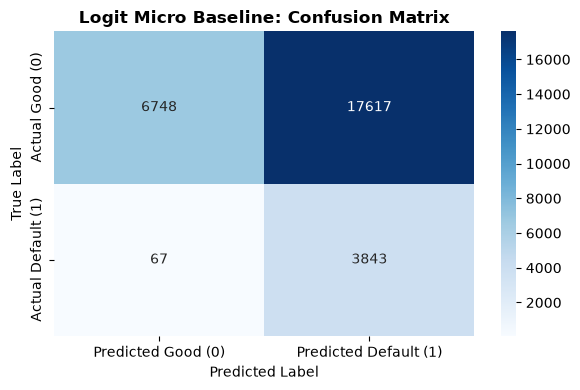

In [22]:

from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
import seaborn as sns
# Generate predictions for the MICRO validation set
y_val_probs_micro = logit_micro.predict_proba(X_val_micro)[:, 1]

# Convert probabilities to hard binary classes (0 or 1) using a standard 0.5 threshold
y_val_pred_micro = (y_val_probs_micro >= 0.14).astype(int)

# Calculate True Baseline Metrics
roc_auc_micro = roc_auc_score(y_val, y_val_probs_micro)
gini_micro = (2 * roc_auc_micro) - 1
pr_auc_micro = average_precision_score(y_val, y_val_probs_micro)

print("\n TRUE Baseline Model Trained! Validation Performance (Micro Only):")
print("-" * 50)
print(f"ROC-AUC Score: {roc_auc_micro:.4f}")
print(f"Gini Index:    {gini_micro:.4f}")
print(f"PR-AUC Score:  {pr_auc_micro:.4f}")
print("-" * 50)

# 4. Classification Report (Precision, Recall, F1-Score per class)
print("\n Classification Report:")
print(classification_report(y_val, y_val_pred_micro, target_names=['Non-Default (0)', 'Default (1)']))
print("-" * 60)

# 5. Confusion Matrix Visualization
print("\n Confusion Matrix:")
cm = confusion_matrix(y_val, y_val_pred_micro)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Good (0)', 'Predicted Default (1)'],
            yticklabels=['Actual Good (0)', 'Actual Default (1)'])
plt.title('Logit Micro Baseline: Confusion Matrix', fontsize=12, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [10]:
print(X_val_micro.isna().sum()[X_val_micro.isna().sum() > 0])

remainder__NUMBER_BORROWERS    9
dtype: int64


In [ ]:
# Extract the training mode (first mode value) and fill the missing values directly
training_mode = X_train_micro['remainder__NUMBER_BORROWERS'].mode()[0]
training_mode

np.float64(0.0)

In [14]:
X_val_micro = X_val_micro.fillna({'remainder__NUMBER_BORROWERS': training_mode})

In [15]:
print(X_val_micro.isna().sum()[X_val_micro.isna().sum() > 0])

Series([], dtype: int64)


In [16]:
print(X_test_micro.isna().sum()[X_val_micro.isna().sum() > 0])

Series([], dtype: int64)


In [25]:
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import warnings

# Mute convergence warnings during fast optimization trials
warnings.filterwarnings('ignore', category=UserWarning)

def objective(trial):
    # 1. Define the hyperparameter search space
    C_param = trial.suggest_float('C', 1e-4, 10.0, log=True)
    l1_ratio_param = trial.suggest_float('l1_ratio', 0.0, 1.0)
    
    # 2. Initialize model with trial parameters
    model = LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        C=C_param,
        l1_ratio=l1_ratio_param,
        class_weight='balanced',
        max_iter=1000,  # Cap iterations slightly for optimization speed
        random_state=42,
        n_jobs=-1
    )
    
    # 3. Fit on the clean micro training set
    model.fit(X_train_micro, y_train)
    
    # 4. Predict probabilities on the validation set
    probs = model.predict_proba(X_val_micro)[:, 1]
    
    # 5. Evaluate using ROC-AUC (maximizing this directly maximizes Gini)
    score = roc_auc_score(y_val, probs)
    return score

print("Initializing Bayesian Optimization via Optuna...")
# Create a study optimized for maximization
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15, n_jobs=1)  # SAGA parallelizes internally via n_jobs=-1

# =====================================================================
# RESULTS REPORTING
# =====================================================================
print("\n Optimization Complete!")
print("-" * 50)
print(f"Best Validation ROC-AUC: {study.best_value:.4f}")
print(f"Best Gini Index:          {(2 * study.best_value) - 1:.4f}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f" -> {key}: {value}")
print("-" * 50)

d:\Credit Risk Model Stress Testing Under Macro Conditions of 2008 Global Recession\Workspace\CRMA_Python\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-06-27 02:14:55,625] A new study created in memory with name: no-name-6d8b339d-ad9e-44ab-beed-ad2cc00c3b81
d:\Credit Risk Model Stress Testing Under Macro Conditions of 2008 Global Recession\Workspace\CRMA_Python\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.

Initializing Bayesian Optimization via Optuna...


[I 2026-06-27 02:15:26,562] Trial 0 finished with value: 0.8545760946979101 and parameters: {'C': 0.02001409860070905, 'l1_ratio': 0.5447096239785153}. Best is trial 0 with value: 0.8545760946979101.
d:\Credit Risk Model Stress Testing Under Macro Conditions of 2008 Global Recession\Workspace\CRMA_Python\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Credit Risk Model Stress Testing Under Macro Conditions of 2008 Global Recession\Workspace\CRMA_Python\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.


 Optimization Complete!
--------------------------------------------------
Best Validation ROC-AUC: 0.8549
Best Gini Index:          0.7098
Best Hyperparameters:
 -> C: 9.021551512393774
 -> l1_ratio: 0.9878317435602773
--------------------------------------------------


In [27]:
print("🏛️ Training finalized, optimized Logistic Regression baseline...")

# Initialize the final baseline model using Optuna's best parameters
best_logit_micro = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    C=9.021551512393774,
    l1_ratio=0.9878317435602773,
    class_weight='balanced',
    max_iter=2000,  # Bump back up to ensure full convergence
    random_state=42,
    n_jobs=-1
)

# Fit on the full training pool
best_logit_micro.fit(X_train_micro, y_train)

print(" Optimized baseline locked and loaded!")

🏛️ Training finalized, optimized Logistic Regression baseline...


d:\Credit Risk Model Stress Testing Under Macro Conditions of 2008 Global Recession\Workspace\CRMA_Python\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Credit Risk Model Stress Testing Under Macro Conditions of 2008 Global Recession\Workspace\CRMA_Python\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


 Optimized baseline locked and loaded!


In [31]:
# Generate final baseline validation probabilities
y_val_probs_micro = best_logit_micro.predict_proba(X_val_micro)[:, 1]

# Apply your portfolio prevalence threshold (0.14) for the risk matrix
y_val_pred_micro = (y_val_probs_micro >= 0.14).astype(int)

# Calculate performance targets
roc_auc_micro = roc_auc_score(y_val, y_val_probs_micro)
gini_micro = (2 * roc_auc_micro) - 1
pr_auc_micro = average_precision_score(y_val, y_val_probs_micro)

print("\n OPTIMIZED MICRO BASELINE METRICS LOCKED:")
print("=" * 60)
print(f"Final Validation ROC-AUC: {roc_auc_micro:.4f}")
print(f"Final Validation Gini:    {gini_micro:.4f}")
print(f"Final Validation PR-AUC:  {pr_auc_micro:.4f}")
print("=" * 60)

print("\n Final Baseline Classification Report (Threshold = 0.14):")
print(classification_report(y_val, y_val_pred_micro, target_names=['Non-Default (0)', 'Default (1)']))


 OPTIMIZED MICRO BASELINE METRICS LOCKED:
Final Validation ROC-AUC: 0.8549
Final Validation Gini:    0.7098
Final Validation PR-AUC:  0.6037

 Final Baseline Classification Report (Threshold = 0.14):
                 precision    recall  f1-score   support

Non-Default (0)       0.99      0.28      0.43     24365
    Default (1)       0.18      0.98      0.30      3910

       accuracy                           0.37     28275
      macro avg       0.58      0.63      0.37     28275
   weighted avg       0.88      0.37      0.42     28275



## Random Forest

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print(" Initializing Random Forest Classifier (Micro Data)...")

# 1. Initialize the Random Forest Engine
# Setting max_depth=10 gives the trees enough room to map complex non-linear structures 
# while preventing deep leaf overfitting before tuning.
rf_micro = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# 2. Fit strictly on the clean micro training data
print("⚙️ Cultivating trees (this may take a few seconds)...")
rf_micro.fit(X_train_micro, y_train)

 Initializing Random Forest Classifier (Micro Data)...
⚙️ Cultivating trees (this may take a few seconds)...


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat


 RANDOM FOREST MICRO BASELINE PERFORMANCE:
Validation ROC-AUC: 0.8554
Validation Gini:    0.7108  (Logit Baseline: 0.7098)
Validation PR-AUC:  0.6139  (Logit Baseline: 0.6037)

 Classification Report (Threshold = 0.14):
                 precision    recall  f1-score   support

Non-Default (0)       0.99      0.18      0.30     24365
    Default (1)       0.16      0.99      0.28      3910

       accuracy                           0.29     28275
      macro avg       0.58      0.58      0.29     28275
   weighted avg       0.88      0.29      0.30     28275

------------------------------------------------------------

🧩 Confusion Matrix:


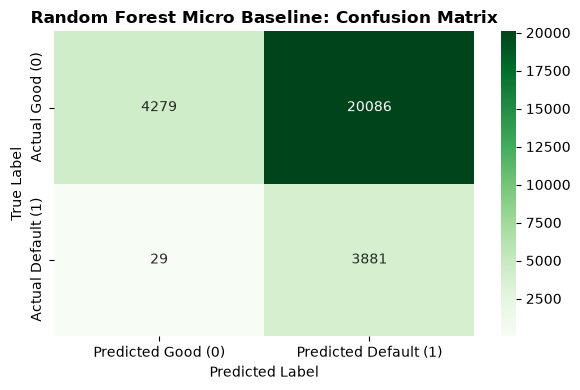

In [34]:
# 3. Generate probability predictions for the validation split
y_val_probs_rf = rf_micro.predict_proba(X_val_micro)[:, 1]

# Apply the portfolio prevalence threshold (0.14) for the hard classification
y_val_pred_rf = (y_val_probs_rf >= 0.14).astype(int)

# 4. Calculate Performance Targets
roc_auc_rf = roc_auc_score(y_val, y_val_probs_rf)
gini_rf = (2 * roc_auc_rf) - 1
pr_auc_rf = average_precision_score(y_val, y_val_probs_rf)

# =====================================================================
# METRICS & VISUALIZATION DASHBOARD
# =====================================================================
print("\n RANDOM FOREST MICRO BASELINE PERFORMANCE:")
print("=" * 60)
print(f"Validation ROC-AUC: {roc_auc_rf:.4f}")
print(f"Validation Gini:    {gini_rf:.4f}  (Logit Baseline: 0.7098)")
print(f"Validation PR-AUC:  {pr_auc_rf:.4f}  (Logit Baseline: 0.6037)")
print("=" * 60)

print("\n Classification Report (Threshold = 0.14):")
print(classification_report(y_val, y_val_pred_rf, target_names=['Non-Default (0)', 'Default (1)']))
print("-" * 60)

print("\n🧩 Confusion Matrix:")
cm_rf = confusion_matrix(y_val, y_val_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Predicted Good (0)', 'Predicted Default (1)'],
            yticklabels=['Actual Good (0)', 'Actual Default (1)'])
plt.title('Random Forest Micro Baseline: Confusion Matrix', fontsize=12, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [37]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

In [38]:
# 1. Dynamically calculate the structural imbalance weight factor
n_neg = np.sum(y_train == 0)
n_pos = np.sum(y_train == 1)
scale_weight = n_neg / n_pos

In [39]:
scale_weight

np.float64(6.232318710832588)

In [41]:
# =====================================================================
#  ARCHITECTURE 1: XGBOOST
# =====================================================================
print("⚔️ Training XGBoost Baseline (Level-Wise Growth)...")
xgb_micro = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)
xgb_micro.fit(X_train_micro, y_train)
y_val_probs_xgb = xgb_micro.predict_proba(X_val_micro)[:, 1]
y_val_pred_xgb = (y_val_probs_xgb >= 0.14).astype(int)

# Metrics
roc_xgb = roc_auc_score(y_val, y_val_probs_xgb)
gini_xgb = (2 * roc_xgb) - 1
pr_xgb = average_precision_score(y_val, y_val_probs_xgb)

⚔️ Training XGBoost Baseline (Level-Wise Growth)...


In [42]:
# =====================================================================
# ARCHITECTURE 2: LIGHTGBM
# =====================================================================
print("⚡ Training LightGBM Baseline (Leaf-Wise Growth)...")
lgb_micro = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    num_leaves=31,
    learning_rate=0.05,
    scale_pos_weight=scale_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_micro.fit(X_train_micro, y_train)
y_val_probs_lgb = lgb_micro.predict_proba(X_val_micro)[:, 1]
y_val_pred_lgb = (y_val_probs_lgb >= 0.14).astype(int)

# Metrics
roc_lgb = roc_auc_score(y_val, y_val_probs_lgb)
gini_lgb = (2 * roc_lgb) - 1
pr_lgb = average_precision_score(y_val, y_val_probs_lgb)

⚡ Training LightGBM Baseline (Leaf-Wise Growth)...


In [44]:
# =====================================================================
#  THE MICRO SHOWDOWN LEAGUE TABLE
# =====================================================================
print("\n THE FINAL MICRO SHOWDOWN RESULTS:")
print("=" * 70)
print(f"Model          | Validation ROC-AUC | Validation Gini | Validation PR-AUC")
print("-" * 70)
print(f"XGBoost Micro  | {roc_xgb:.4f}             | {gini_xgb:.4f}          | {pr_xgb:.4f}")
print(f"LightGBM Micro | {roc_lgb:.4f}             | {gini_lgb:.4f}          | {pr_lgb:.4f}")
print("=" * 70)

print("\n XGBoost Report (Threshold = 0.14):")
print(classification_report(y_val, y_val_pred_xgb, digits=4))

print("\n LightGBM Report (Threshold = 0.14):")
print(classification_report(y_val, y_val_pred_lgb, digits=4))


 THE FINAL MICRO SHOWDOWN RESULTS:
Model          | Validation ROC-AUC | Validation Gini | Validation PR-AUC
----------------------------------------------------------------------
XGBoost Micro  | 0.8649             | 0.7298          | 0.6313
LightGBM Micro | 0.8653             | 0.7307          | 0.6321

 XGBoost Report (Threshold = 0.14):
              precision    recall  f1-score   support

           0     0.9885    0.3488    0.5156     24365
           1     0.1937    0.9747    0.3231      3910

    accuracy                         0.4353     28275
   macro avg     0.5911    0.6617    0.4194     28275
weighted avg     0.8786    0.4353    0.4890     28275


 LightGBM Report (Threshold = 0.14):
              precision    recall  f1-score   support

           0     0.9876    0.3472    0.5138     24365
           1     0.1930    0.9729    0.3221      3910

    accuracy                         0.4337     28275
   macro avg     0.5903    0.6601    0.4180     28275
weighted avg     0.

In [45]:
# 2. Calculate standard confusion matrices
cm_xgb = confusion_matrix(y_val, y_val_pred_xgb)
cm_lgb = confusion_matrix(y_val, y_val_pred_lgb)

In [49]:
cm_xgb

array([[ 8498, 15867],
       [   99,  3811]])

In [48]:
cm_lgb

array([[ 8460, 15905],
       [  106,  3804]])

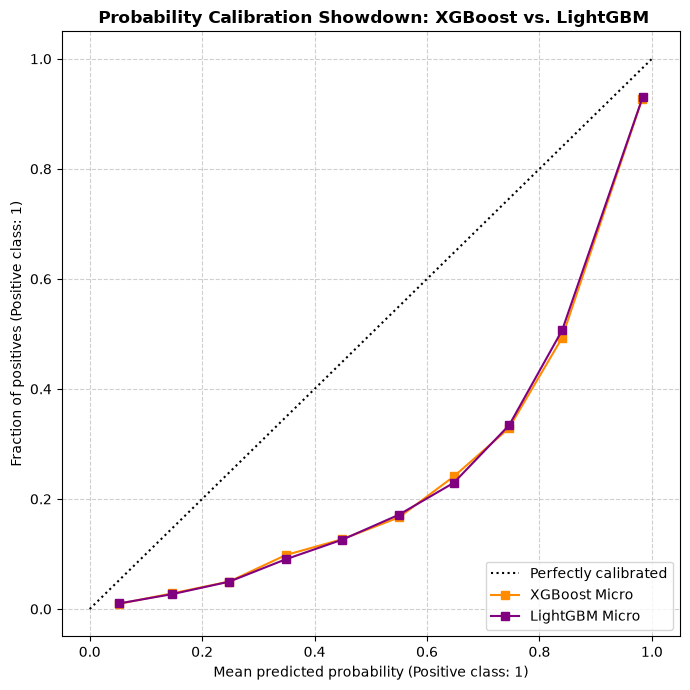

In [50]:
import matplotlib.pyplot as plt
from sklearn.calibration import CalibrationDisplay

# 1. Initialize a single plot environment for direct overlay comparison
fig, ax = plt.subplots(figsize=(7, 7))

# 2. Plot XGBoost Calibration Curve
CalibrationDisplay.from_estimator(
    xgb_micro, X_val_micro, y_val, 
    n_bins=10, ax=ax, name="XGBoost Micro", color="darkorange"
)

# 3. Plot LightGBM Calibration Curve on the same axis
CalibrationDisplay.from_estimator(
    lgb_micro, X_val_micro, y_val, 
    n_bins=10, ax=ax, name="LightGBM Micro", color="purple"
)

# 4. Polish the institutional styling
ax.set_title(" Probability Calibration Showdown: XGBoost vs. LightGBM", fontsize=12, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [51]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

print(" Training Raw, Unweighted LightGBM Champion (True Distribution Mode)...")

# Initialize without scale_pos_weight or is_unbalance
lgb_raw = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    num_leaves=31,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# Fit on the clean micro training set
lgb_raw.fit(X_train_micro, y_train)

 Training Raw, Unweighted LightGBM Champion (True Distribution Mode)...


,max_depth,6
,learning_rate,0.05
,n_estimators,200
,random_state,42
,n_jobs,-1
,verbose,-1
,boosting_type,'gbdt'
,num_leaves,31
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [52]:
# Generate true, unwarped validation probabilities
y_val_probs_raw = lgb_raw.predict_proba(X_val_micro)[:, 1]

# Apply the portfolio prevalence threshold (0.14) to catch defaults
y_val_pred_raw = (y_val_probs_raw >= 0.14).astype(int)

# Calculate Performance Metrics
roc_raw = roc_auc_score(y_val, y_val_probs_raw)
gini_raw = (2 * roc_raw) - 1
pr_raw = average_precision_score(y_val, y_val_probs_raw)

print("\n🏆 UNWEIGHTED LIGHTGBM PERFORMANCE (Threshold = 0.14):")
print("=" * 60)
print(f"Validation ROC-AUC: {roc_raw:.4f}")
print(f"Validation Gini:    {gini_raw:.4f}  (Weighted LGBM: 0.7307)")
print(f"Validation PR-AUC:  {pr_raw:.4f}  (Weighted LGBM: 0.6321)")
print("=" * 60)

print("\n🧩 Raw Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_raw))


🏆 UNWEIGHTED LIGHTGBM PERFORMANCE (Threshold = 0.14):
Validation ROC-AUC: 0.8655
Validation Gini:    0.7310  (Weighted LGBM: 0.7307)
Validation PR-AUC:  0.6330  (Weighted LGBM: 0.6321)

🧩 Raw Confusion Matrix:
[[19385  4980]
 [  977  2933]]


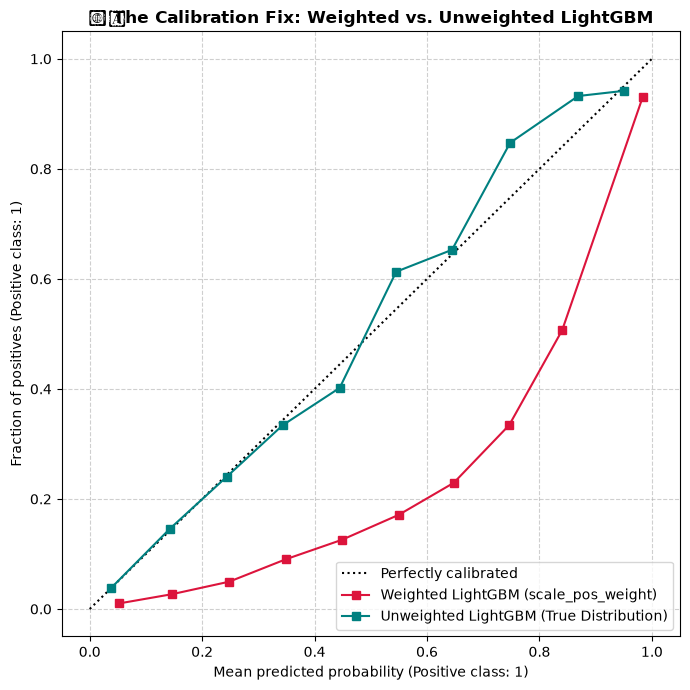

In [56]:
import matplotlib.pyplot as plt
from sklearn.calibration import CalibrationDisplay

# 1. Initialize the plot environment
fig, ax = plt.subplots(figsize=(7, 7))

# 2. Plot the old Weighted LightGBM (The bowed curve)
CalibrationDisplay.from_estimator(
    lgb_micro, X_val_micro, y_val, 
    n_bins=10, ax=ax, name="Weighted LightGBM (scale_pos_weight)", color="crimson"
)

# 3. Plot the new Unweighted LightGBM Champion
CalibrationDisplay.from_estimator(
    lgb_raw, X_val_micro, y_val, 
    n_bins=10, ax=ax, name="Unweighted LightGBM (True Distribution)", color="teal"
)

# 4. Final institutional styling
ax.set_title("🏛️ The Calibration Fix: Weighted vs. Unweighted LightGBM", fontsize=12, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [58]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

print("⚔️ Training Raw, Unweighted XGBoost Champion (True Distribution Mode)...")

# 1. Initialize without scale_pos_weight
xgb_raw = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

# 2. Fit strictly on the micro training set
xgb_raw.fit(X_train_micro, y_train)

# 3. Generate true validation probabilities and apply the 0.14 threshold
y_val_probs_xgb_raw = xgb_raw.predict_proba(X_val_micro)[:, 1]
y_val_pred_xgb_raw = (y_val_probs_xgb_raw >= 0.14).astype(int)

# 4. Calculate Performance Metrics
roc_xgb_raw = roc_auc_score(y_val, y_val_probs_xgb_raw)
gini_xgb_raw = (2 * roc_xgb_raw) - 1
pr_xgb_raw = average_precision_score(y_val, y_val_probs_xgb_raw)

print("\n🏆 UNWEIGHTED XGBOOST PERFORMANCE (Threshold = 0.14):")
print("=" * 60)
print(f"Validation ROC-AUC: {roc_xgb_raw:.4f}")
print(f"Validation Gini:    {gini_xgb_raw:.4f}  (Weighted XGBoost: 0.7298)")
print(f"Validation PR-AUC:  {pr_xgb_raw:.4f}  (Weighted XGBoost: 0.6313)")
print("=" * 60)

print("\n📊 Classification Report (Threshold = 0.14):")
print(classification_report(y_val, y_val_pred_xgb_raw, digits=4))

print("\n🧩 Raw Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_xgb_raw))

⚔️ Training Raw, Unweighted XGBoost Champion (True Distribution Mode)...

🏆 UNWEIGHTED XGBOOST PERFORMANCE (Threshold = 0.14):
Validation ROC-AUC: 0.8654
Validation Gini:    0.7308  (Weighted XGBoost: 0.7298)
Validation PR-AUC:  0.6325  (Weighted XGBoost: 0.6313)

📊 Classification Report (Threshold = 0.14):
              precision    recall  f1-score   support

           0     0.9516    0.7962    0.8670     24365
           1     0.3706    0.7476    0.4955      3910

    accuracy                         0.7895     28275
   macro avg     0.6611    0.7719    0.6813     28275
weighted avg     0.8712    0.7895    0.8156     28275


🧩 Raw Confusion Matrix:
[[19400  4965]
 [  987  2923]]


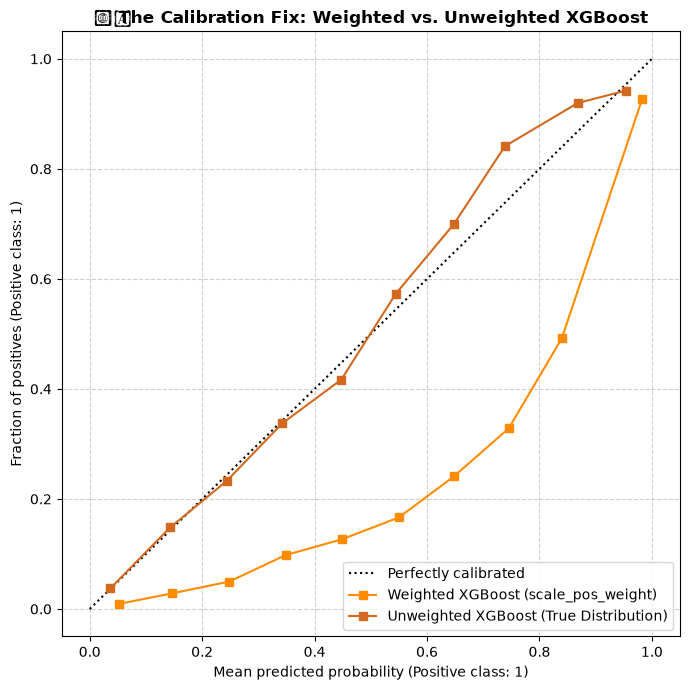

In [60]:
import matplotlib.pyplot as plt
from sklearn.calibration import CalibrationDisplay

# 1. Initialize the plot environment
fig, ax = plt.subplots(figsize=(7, 7))

# 2. Plot the old Weighted XGBoost (The distorted curve)
CalibrationDisplay.from_estimator(
    xgb_micro, X_val_micro, y_val, 
    n_bins=10, ax=ax, name="Weighted XGBoost (scale_pos_weight)", color="darkorange"
)

# 3. Plot the new Unweighted XGBoost Champion
CalibrationDisplay.from_estimator(
    xgb_raw, X_val_micro, y_val, 
    n_bins=10, ax=ax, name="Unweighted XGBoost (True Distribution)", color="chocolate"
)

# 4. Final institutional styling
ax.set_title("🏛️ The Calibration Fix: Weighted vs. Unweighted XGBoost", fontsize=12, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

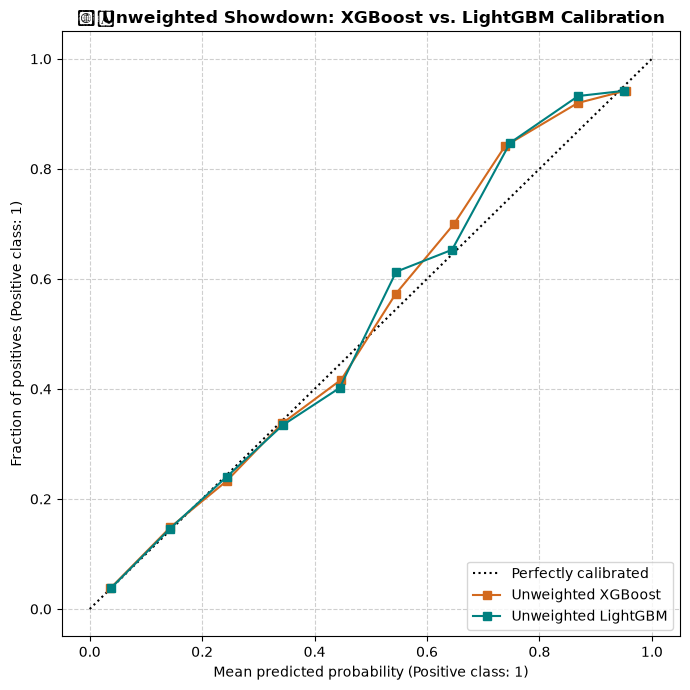

In [61]:
import matplotlib.pyplot as plt
from sklearn.calibration import CalibrationDisplay

# 1. Initialize a clean, single plot axis
fig, ax = plt.subplots(figsize=(7, 7))

# 2. Plot the Unweighted XGBoost Curve
CalibrationDisplay.from_estimator(
    xgb_raw, X_val_micro, y_val, 
    n_bins=10, ax=ax, name="Unweighted XGBoost", color="chocolate"
)

# 3. Plot the Unweighted LightGBM Curve on the same axis
CalibrationDisplay.from_estimator(
    lgb_raw, X_val_micro, y_val, 
    n_bins=10, ax=ax, name="Unweighted LightGBM", color="teal"
)

# 4. Apply institutional styling for your dissertation
ax.set_title("🏛️ Unweighted Showdown: XGBoost vs. LightGBM Calibration", fontsize=12, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()